In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import pyplot as plt
import pickle

from aquacrop_slovenia.yield_projections import run_all_projections, get_model_scenario_combinations, \
    compute_period_statistics
from aquacrop_slovenia import config

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"

In [4]:
# takes about 7 mins to run!
projections = run_all_projections(LOCATION)
pickle.dump(projections, open(config.RESULTS_DIR / f"projections_v1_{LOCATION}.pkl", "wb"))

Running projection for jablje with model1 and rcp45
Setting up working directory at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3
Running AquaCrop simulation with project file: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed
Running projection for jablje with model1 and rcp85
Setting up working directory at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3
Running AquaCrop simulation with project file: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Doc

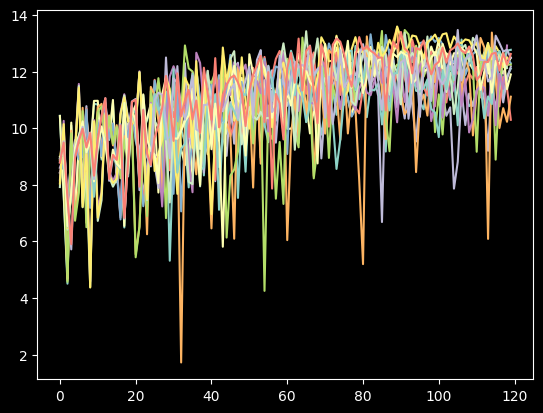

In [5]:
for model, scenario in get_model_scenario_combinations(LOCATION):
    plt.plot(projections[(model, scenario)].loc[:, "Y(dry)"])

In [36]:
projections[("model1", "rcp45")]

,Year1,Y(dry)
0,1981,8.469
1,1982,8.863
2,1983,7.532
3,1984,9.214
4,1985,8.700
...,...,...
115,2096,11.992
116,2097,10.464
117,2098,11.737
118,2099,12.374


In [14]:
for model, scenario in get_model_scenario_combinations(LOCATION):
    print(f"{model}, {scenario}")
    print(compute_period_statistics(projections[(model, scenario)]))
    print()

model1, rcp45
                Mean       Std    Min   Median     Max
Period                                                
1981-2010   8.458367  2.365357  0.885   9.0895  10.987
2011-2040   9.973833  2.105568  0.000  10.1665  12.279
2041-2070   9.083233  3.671641  0.131  10.5485  12.702
2071-2100  10.359333  2.922102  1.256  11.4990  13.123

model1, rcp85
                Mean       Std    Min   Median     Max
Period                                                
1981-2010   8.779733  1.982122  1.458   9.0230  10.817
2011-2040   9.069500  2.824703  0.259   9.8930  11.435
2041-2070  10.476100  2.814462  0.000  11.4235  12.870
2071-2100  10.984667  2.699895  1.860  12.0915  12.896

model2, rcp26
                Mean       Std    Min   Median     Max
Period                                                
1981-2010   9.722633  1.012638  6.244   9.7430  11.218
2011-2040  10.141733  1.739922  3.421  10.6860  12.029
2041-2070   9.428233  2.937599  1.515  10.3600  12.329
2071-2100  10.635333 

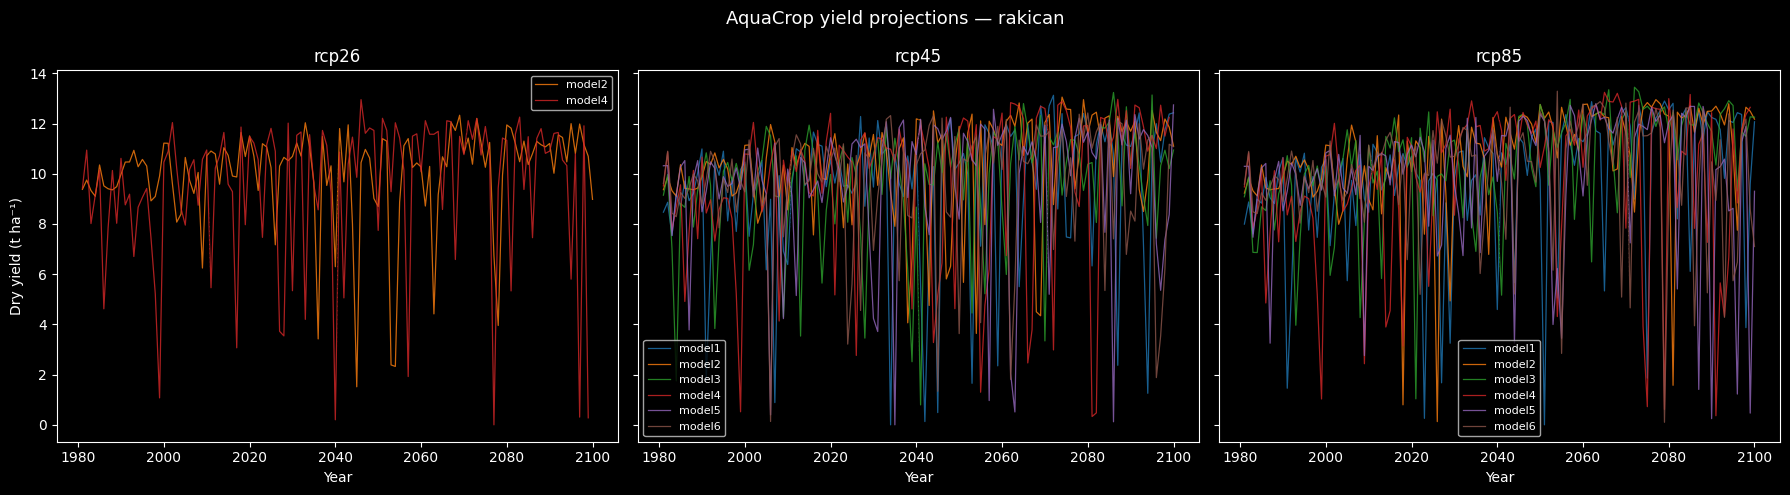

In [22]:
from aquacrop_slovenia.yield_projections import PERIODS

scenarios = sorted({sc for _, sc in projections})
model_names = sorted({model for model, _ in projections})
colors = plt.cm.tab10.colors
period_boundaries = [start for start, _ in PERIODS.values() if start > 1981]

fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 5), sharey=True)
if len(scenarios) == 1:
    axes = [axes]

for ax, scenario in zip(axes, scenarios):
    for i, model in enumerate(model_names):
        if (model, scenario) not in projections:
            continue
        result = projections[(model, scenario)]
        ax.plot(result["Year1"], result["Y(dry)"], color=colors[i % len(colors)], linewidth=0.9, alpha=0.8, label=model)

    for year in period_boundaries:
        ax.axvline(year - 0.5, color="black", linewidth=0.6, linestyle="--", alpha=0.4)

    ax.set_title(scenario)
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Dry yield (t ha⁻¹)")
fig.suptitle(f"AquaCrop yield projections — {LOCATION}", fontsize=13)
fig.tight_layout()
plt.show()

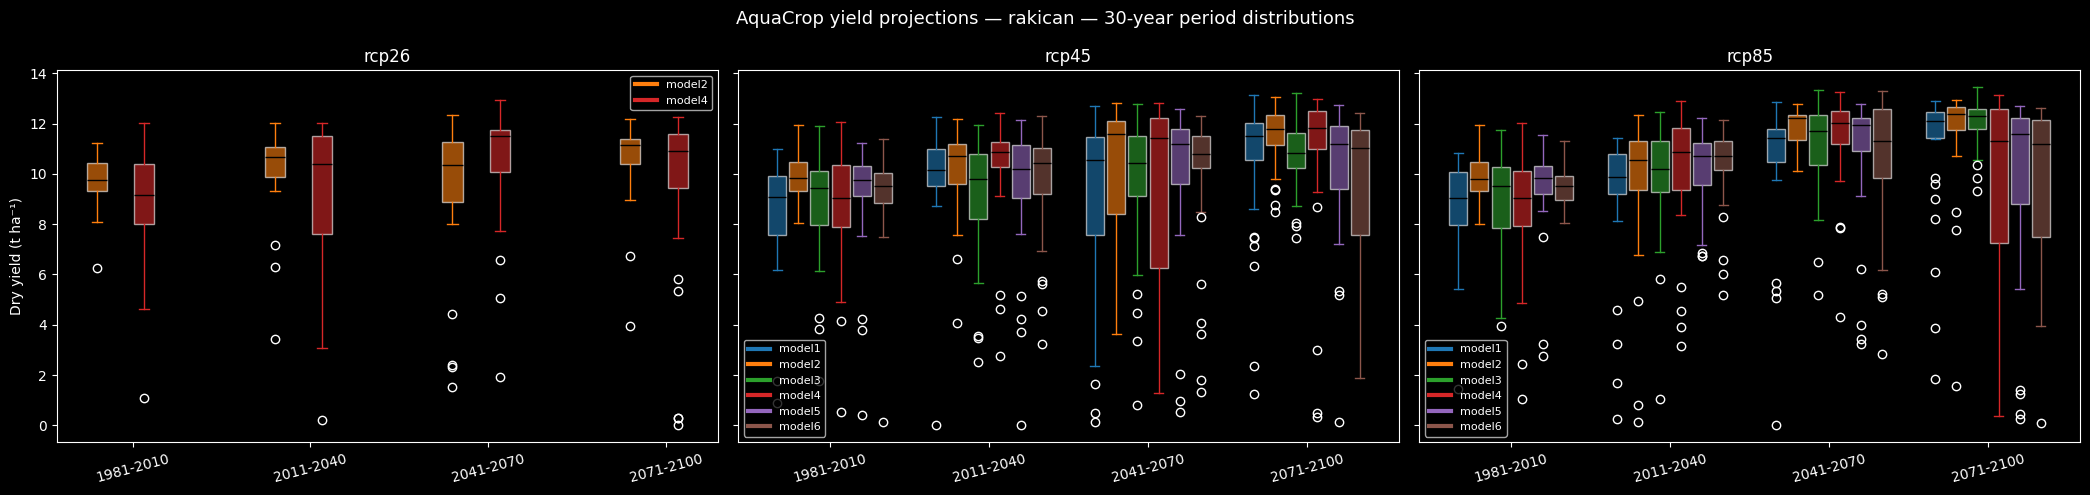

In [26]:
period_labels = list(PERIODS.keys())
n_periods = len(period_labels)
n_models = len(model_names)
group_width = 0.8
box_width = group_width / n_models

fig, axes = plt.subplots(1, len(scenarios), figsize=(7 * len(scenarios), 5), sharey=True)
if len(scenarios) == 1:
    axes = [axes]

for ax, scenario in zip(axes, scenarios):
    for i, model in enumerate(model_names):
        if (model, scenario) not in projections:
            continue
        result = projections[(model, scenario)]
        color = colors[i % len(colors)]
        positions, data = [], []
        for j, (label, (start, end)) in enumerate(PERIODS.items()):
            s = result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"].values
            positions.append(j + (i - (n_models - 1) / 2) * box_width)
            data.append(s)

        bp = ax.boxplot(data, positions=positions, widths=box_width * 0.85,
                        patch_artist=True, manage_ticks=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        for key in ("whiskers", "caps", "fliers"):
            for line in bp[key]:
                line.set_color(color)
        for line in bp["medians"]:
            line.set_color("black")
        ax.plot([], [], color=color, linewidth=3, label=model)

    ax.set_xticks(range(n_periods))
    ax.set_xticklabels(period_labels, rotation=15)
    ax.set_title(scenario)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Dry yield (t ha⁻¹)")
fig.suptitle(f"AquaCrop yield projections — {LOCATION} — 30-year period distributions", fontsize=13)
fig.tight_layout()
plt.show()

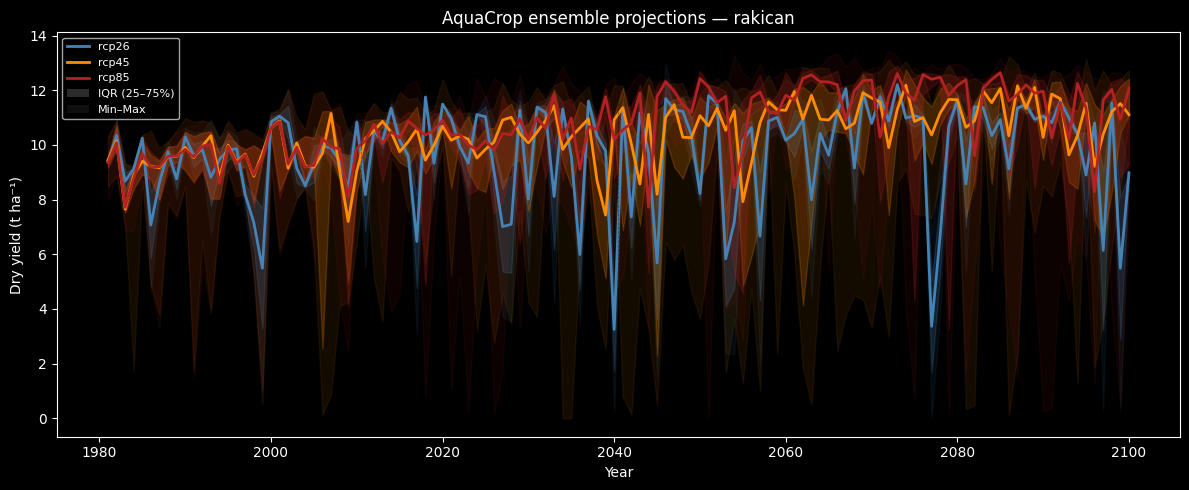

In [42]:
import pandas as pd
from matplotlib.patches import Patch

scenario_colors = {"rcp26": "steelblue", "rcp45": "darkorange", "rcp85": "firebrick"}

fig, ax = plt.subplots(figsize=(12, 5))

for scenario in scenarios:
    frames = [
        projections[(model, scenario)].set_index("Year1")["Y(dry)"].rename(model)
        for model in model_names
        if (model, scenario) in projections
    ]
    ensemble = pd.concat(frames, axis=1)
    color = scenario_colors.get(scenario, "gray")

    ax.fill_between(ensemble.index, ensemble.min(axis=1), ensemble.max(axis=1),
                    alpha=0.08, color=color)
    ax.fill_between(ensemble.index, ensemble.quantile(0.25, axis=1), ensemble.quantile(0.75, axis=1),
                    alpha=0.2, color=color)
    ax.plot(ensemble.index, ensemble.median(axis=1), color=color, linewidth=2, label=scenario)

for year in period_boundaries:
    ax.axvline(year - 0.5, color="black", linewidth=0.6, linestyle="--", alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
handles += [
    Patch(facecolor="gray", alpha=0.35, label="IQR (25–75%)"),
    Patch(facecolor="gray", alpha=0.12, label="Min–Max"),
]
ax.legend(handles=handles, fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("Dry yield (t ha⁻¹)")
ax.set_title(f"AquaCrop ensemble projections — {LOCATION}")
fig.tight_layout()
plt.show()